# Exploratory Analysis

This notebook checks whether the value metrics behave sensibly before I use them for modeling. The goal is not just to make charts; it is to understand what the metric rewards, where it may be biased, and which patterns need to be explained carefully.

I focus on total EPA value, per-game context, position differences, age and experience patterns, and relationships with supporting box-score statistics.


## Load Value Scores

This section loads the value-score dataset from Notebook 03. At this point, each row should represent one qualifying player-season, with traded-player stints already collapsed.

The path logic lets the notebook run from VS Code, Jupyter, or the project root without manually changing file paths.


In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

def find_project_root(expected_file):
    """Find the repo root from common VS Code/Jupyter working directories."""
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / expected_file).exists():
            return candidate
    raise FileNotFoundError(
        "Could not find " + expected_file + " from working directory " + str(Path.cwd())
    )

project_root = find_project_root("data/processed/player_value_scores_2016_2025.csv")
processed_dir = project_root / "data" / "processed"
figures_dir = project_root / "outputs" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

value_scores_path = processed_dir / "player_value_scores_2016_2025.csv"
value_scored = pd.read_csv(value_scores_path)

print(value_scored.shape)
value_scored.head()


(4753, 81)


,season,player_id,completions,attempts,passing_yards,passing_tds,passing_interceptions,sacks_suffered,sack_yards_lost,passing_air_yards,...,value_epa_total,value_epa_per_game,value_score,value_score_per_game,value_score_gap,value_score_total_epa,value_metric,team,position_season_rank,position_season_percentile
0,2016,00-0019596,291,432,3554,28,2,15,-87,3353,...,140.632333,11.719361,2.127596,2.264787,0.137191,2.127596,position_adjusted_total_epa,NE,3.0,0.960000
1,2016,00-0020337,0,0,0,0,0,0,0,0,...,37.947165,2.710512,1.390061,1.430829,0.040768,1.390061,position_adjusted_total_epa,BAL,18.0,0.903409
2,2016,00-0020531,471,673,5208,37,15,27,-184,4795,...,105.672159,6.604510,1.491620,1.172466,-0.319155,1.491620,position_adjusted_total_epa,NO,6.0,0.900000
3,2016,00-0021206,90,165,1100,6,6,18,-126,1649,...,-29.051473,-5.810295,-0.959196,-1.478825,-0.519629,-0.959196,position_adjusted_total_epa,CLE,45.0,0.120000
4,2016,00-0021429,364,597,4233,26,14,40,-281,5635,...,26.261320,1.750755,0.047023,0.135903,0.088880,0.047023,position_adjusted_total_epa,ARI,20.0,0.620000


## Quick Data Checks

Before interpreting any plots, I check the basic structure of the data. Duplicate player-season rows, missing metric columns, or unexpected row counts would make the later rankings and charts misleading.


In [2]:
required_cols = [
    "season", "player_id", "player_display_name", "position", "team",
    "games_played", "value_epa_total", "value_epa_per_game",
    "value_score", "value_score_per_game",
    "position_season_rank", "position_season_percentile"
]

missing_cols = [col for col in required_cols if col not in value_scored.columns]
print("Missing columns:", missing_cols)

duplicate_rows = value_scored.duplicated(["season", "player_id"]).sum()
print("Duplicate player-season rows:", duplicate_rows)

print("Seasons:", sorted(value_scored["season"].dropna().unique()))
print("Positions:", value_scored["position"].value_counts().to_dict())

value_scored[[
    "value_epa_total", "value_epa_per_game", "value_score", "value_score_per_game"
]].describe()


Missing columns: []
Duplicate player-season rows: 0
Seasons: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Positions: {'WR': 1929, 'RB': 1236, 'TE': 1041, 'QB': 547}


,value_epa_total,value_epa_per_game,value_score,value_score_per_game
count,4753.000000,4753.000000,4.753000e+03,4.753000e+03
mean,6.860579,0.382395,1.214635e-17,2.092909e-17
std,26.370422,2.079964,9.958880e-01,9.958880e-01
min,-146.750158,-14.526440,-6.206965e+00,-4.616463e+00
25%,-4.362173,-0.462706,-6.089288e-01,-6.219794e-01
50%,2.041011,0.208134,-1.820937e-01,-9.113587e-02
75%,13.469360,1.131271,4.629219e-01,5.522944e-01
max,237.035261,14.814704,6.057176e+00,5.614646e+00


## Add Diagnostic Columns

`value_score_gap` compares per-game standardized value to total-EPA standardized value. I use it as a diagnostic, not as a new value metric.

A large positive gap usually means a player looked better on a per-game basis than as a full-season contributor. That can happen because of missed games, changing roles, or small samples.


In [3]:
value_scored = value_scored.copy()
value_scored["value_score_gap"] = value_scored["value_score_per_game"] - value_scored["value_score"]

value_scored[[
    "player_display_name", "season", "position", "team", "games_played",
    "value_epa_total", "value_epa_per_game", "value_score",
    "value_score_per_game", "value_score_gap"
]].sort_values("value_score_gap", ascending=False).head(10)


,player_display_name,season,position,team,games_played,value_epa_total,value_epa_per_game,value_score,value_score_per_game,value_score_gap
4280,Tyreek Hill,2025,WR,MIA,4,19.834595,4.958649,0.485252,3.123034,2.637781
4168,Rashee Rice,2024,WR,KC,4,18.822884,4.705721,0.334204,2.618658,2.284454
2409,Maxx Williams,2021,TE,ARI,5,15.071474,3.014295,0.651363,2.655027,2.003664
2082,Kenny Golladay,2020,WR,DET,5,21.662457,4.332491,0.323285,2.177976,1.854691
3854,Chris Godwin Jr.,2024,WR,TB,7,37.047007,5.292430,1.242907,3.015797,1.772891
2339,Antonio Brown,2021,WR,TB,7,34.262215,4.894602,1.099235,2.832960,1.733725
1680,Will Dissly,2019,TE,SEA,6,19.106299,3.184383,0.820208,2.522429,1.702221
4588,Tucker Kraft,2025,TE,GB,8,38.442761,4.805345,2.054947,3.670778,1.615831
4680,Ashton Jeanty,2025,RB,LV,17,-77.057753,-4.532809,-6.206965,-4.616463,1.590502
4656,Jalen McMillan,2025,WR,TB,4,12.027500,3.006875,0.071737,1.658745,1.587008


## Top Full-Season Value by Position

These tables use `value_epa_total`, the raw full-season EPA metric. This is the most direct way to see how much expected-point value a player added over the season.

I separate the tables by position because the project is intentionally position-aware. A QB and a WR should not be judged on the same raw scale without context.


In [4]:
season_to_check = 2024

for pos in ["QB", "RB", "WR", "TE"]:
    print()
    print("Top", pos + "s", "by total EPA in", season_to_check)
    display(
        value_scored[
            (value_scored["season"] == season_to_check) &
            (value_scored["position"] == pos)
        ][[
            "player_display_name", "team", "games_played",
            "value_epa_total", "value_epa_per_game",
            "value_score", "position_season_rank"
        ]]
        .sort_values("value_epa_total", ascending=False)
        .head(10)
    )



Top QBs by total EPA in 2024


,player_display_name,team,games_played,value_epa_total,value_epa_per_game,value_score,position_season_rank
3894,Josh Allen,BUF,16,187.113574,11.694598,2.753053,1.0
3885,Lamar Jackson,BAL,17,183.931545,10.819503,2.701035,2.0
3819,Jared Goff,DET,17,165.429827,9.731166,2.398578,3.0
3981,Joe Burrow,CIN,17,131.179774,7.716457,1.838674,4.0
3893,Baker Mayfield,TB,17,122.182661,7.187215,1.691593,5.0
4239,Jayden Daniels,WAS,17,119.373123,7.021948,1.645664,6.0
4078,Brock Purdy,SF,15,97.007326,6.467155,1.280039,7.0
3846,Patrick Mahomes,KC,16,95.446626,5.965414,1.254526,8.0
3950,Tua Tagovailoa,MIA,11,86.305197,7.845927,1.105086,9.0
3907,Kyler Murray,ARI,17,83.587614,4.916918,1.060660,10.0



Top RBs by total EPA in 2024


,player_display_name,team,games_played,value_epa_total,value_epa_per_game,value_score,position_season_rank
4171,Jahmyr Gibbs,DET,17,50.032154,2.943068,3.281628,1.0
3812,Derrick Henry,BAL,17,49.606434,2.918026,3.256081,2.0
3891,Saquon Barkley,PHI,16,49.461172,3.091323,3.247364,3.0
4188,Bucky Irving,TB,17,35.450351,2.085315,2.406612,4.0
4106,Bijan Robinson,ATL,17,25.584958,1.504998,1.814616,5.0
3921,Ty Johnson,BUF,17,24.069822,1.415872,1.723697,6.0
4041,James Cook,BUF,16,23.395136,1.462196,1.683211,7.0
3841,Austin Ekeler,WAS,12,18.801500,1.566792,1.407559,8.0
4150,Sean Tucker,TB,17,17.547465,1.032204,1.332308,9.0
3900,Justice Hill,BAL,15,14.844525,0.989635,1.170111,10.0



Top WRs by total EPA in 2024


,player_display_name,team,games_played,value_epa_total,value_epa_per_game,value_score,position_season_rank
4017,Amon-Ra St. Brown,DET,17,95.743892,5.631994,4.169688,1.0
4010,Ja'Marr Chase,CIN,17,79.032173,4.648951,3.336398,2.0
4241,Ladd McConkey,LAC,16,65.707443,4.106715,2.671992,3.0
3930,Terry McLaurin,WAS,17,64.637547,3.802209,2.618644,4.0
3964,Justin Jefferson,MIN,17,63.974392,3.763200,2.585577,5.0
3931,A.J. Brown,PHI,13,61.811166,4.754705,2.477713,6.0
4235,Brian Thomas Jr.,JAX,17,56.810445,3.341791,2.228364,7.0
3974,Tee Higgins,CIN,12,56.401296,4.700108,2.207963,8.0
4012,DeVonta Smith,PHI,13,56.324606,4.332662,2.204139,9.0
4170,Puka Nacua,LA,11,54.491021,4.953729,2.112711,10.0



Top TEs by total EPA in 2024


,player_display_name,team,games_played,value_epa_total,value_epa_per_game,value_score,position_season_rank
3825,George Kittle,SF,15,67.944928,4.529662,4.128084,1.0
3844,Jonnu Smith,MIA,17,58.068716,3.415807,3.443435,2.0
3880,Mark Andrews,BAL,17,53.545150,3.149715,3.129847,3.0
4072,Trey McBride,ARI,16,49.672450,3.104528,2.861379,4.0
4155,Tucker Kraft,GB,17,40.513069,2.383122,2.226422,5.0
4008,Pat Freiermuth,PIT,17,35.901233,2.111837,1.906715,6.0
3888,Mike Gesicki,CIN,16,33.767575,2.110473,1.758804,7.0
4166,Sam LaPorta,DET,16,31.423357,1.963960,1.596295,8.0
3781,Zach Ertz,WAS,17,30.982541,1.822502,1.565736,9.0
4080,Isaiah Likely,BAL,15,27.706500,1.847100,1.338631,10.0


## Top Per-Game Value by Position

These tables use `value_epa_per_game`. This rate view is useful, but it needs to be read next to `games_played`.

A high per-game number can identify a very efficient player, but it does not always mean that player created the most total season value.


In [5]:
for pos in ["QB", "RB", "WR", "TE"]:
    print()
    print("Top", pos + "s", "by EPA per game in", season_to_check)
    display(
        value_scored[
            (value_scored["season"] == season_to_check) &
            (value_scored["position"] == pos)
        ][[
            "player_display_name", "team", "games_played",
            "value_epa_total", "value_epa_per_game",
            "value_score", "value_score_per_game"
        ]]
        .sort_values("value_epa_per_game", ascending=False)
        .head(10)
    )



Top QBs by EPA per game in 2024


,player_display_name,team,games_played,value_epa_total,value_epa_per_game,value_score,value_score_per_game
3894,Josh Allen,BUF,16,187.113574,11.694598,2.753053,2.341023
3885,Lamar Jackson,BAL,17,183.931545,10.819503,2.701035,2.157571
3819,Jared Goff,DET,17,165.429827,9.731166,2.398578,1.929417
3950,Tua Tagovailoa,MIA,11,86.305197,7.845927,1.105086,1.534202
3981,Joe Burrow,CIN,17,131.179774,7.716457,1.838674,1.507061
3893,Baker Mayfield,TB,17,122.182661,7.187215,1.691593,1.396113
4239,Jayden Daniels,WAS,17,119.373123,7.021948,1.645664,1.361467
4078,Brock Purdy,SF,15,97.007326,6.467155,1.280039,1.245162
3846,Patrick Mahomes,KC,16,95.446626,5.965414,1.254526,1.139979
3972,Jalen Hurts,PHI,15,81.159946,5.410663,1.020974,1.023683



Top RBs by EPA per game in 2024


,player_display_name,team,games_played,value_epa_total,value_epa_per_game,value_score,value_score_per_game
3891,Saquon Barkley,PHI,16,49.461172,3.091323,3.247364,2.853899
4171,Jahmyr Gibbs,DET,17,50.032154,2.943068,3.281628,2.734774
3812,Derrick Henry,BAL,17,49.606434,2.918026,3.256081,2.714652
4188,Bucky Irving,TB,17,35.450351,2.085315,2.406612,2.045559
3841,Austin Ekeler,WAS,12,18.801500,1.566792,1.407559,1.628920
4106,Bijan Robinson,ATL,17,25.584958,1.504998,1.814616,1.579267
4041,James Cook,BUF,16,23.395136,1.462196,1.683211,1.544876
3921,Ty Johnson,BUF,17,24.069822,1.415872,1.723697,1.507654
4124,Chris Rodriguez Jr.,WAS,7,9.078644,1.296949,0.824116,1.412098
4150,Sean Tucker,TB,17,17.547465,1.032204,1.332308,1.199372



Top WRs by EPA per game in 2024


,player_display_name,team,games_played,value_epa_total,value_epa_per_game,value_score,value_score_per_game
4017,Amon-Ra St. Brown,DET,17,95.743892,5.631994,4.169688,3.245646
3854,Chris Godwin Jr.,TB,7,37.047007,5.292430,1.242907,3.015797
4170,Puka Nacua,LA,11,54.491021,4.953729,2.112711,2.786533
3931,A.J. Brown,PHI,13,61.811166,4.754705,2.477713,2.651815
4168,Rashee Rice,KC,4,18.822884,4.705721,0.334204,2.618658
3974,Tee Higgins,CIN,12,56.401296,4.700108,2.207963,2.614858
4010,Ja'Marr Chase,CIN,17,79.032173,4.648951,3.336398,2.580230
4012,DeVonta Smith,PHI,13,56.324606,4.332662,2.204139,2.366136
4241,Ladd McConkey,LAC,16,65.707443,4.106715,2.671992,2.213194
3780,Adam Thielen,CAR,10,40.429083,4.042908,1.411546,2.170003



Top TEs by EPA per game in 2024


,player_display_name,team,games_played,value_epa_total,value_epa_per_game,value_score,value_score_per_game
3825,George Kittle,SF,15,67.944928,4.529662,4.128084,3.951506
3844,Jonnu Smith,MIA,17,58.068716,3.415807,3.443435,2.843526
3880,Mark Andrews,BAL,17,53.545150,3.149715,3.129847,2.578837
3829,Taysom Hill,NO,8,25.166487,3.145811,1.162549,2.574954
4072,Trey McBride,ARI,16,49.672450,3.104528,2.861379,2.533889
4155,Tucker Kraft,GB,17,40.513069,2.383122,2.226422,1.816287
4008,Pat Freiermuth,PIT,17,35.901233,2.111837,1.906715,1.546433
3888,Mike Gesicki,CIN,16,33.767575,2.110473,1.758804,1.545076
4166,Sam LaPorta,DET,16,31.423357,1.963960,1.596295,1.399335
3869,Dallas Goedert,PHI,10,19.366237,1.936624,0.760458,1.372143


## Total Value vs Per-Game Value

This is one of the most important methodology checks in the notebook. The chart compares standardized per-game EPA with standardized total EPA.

Players in the upper-right were strong by both views. Players far to the right but not high on the y-axis were productive when active but did not accumulate as much total season value. This is why I chose total EPA as the primary value metric and kept per-game EPA as context.


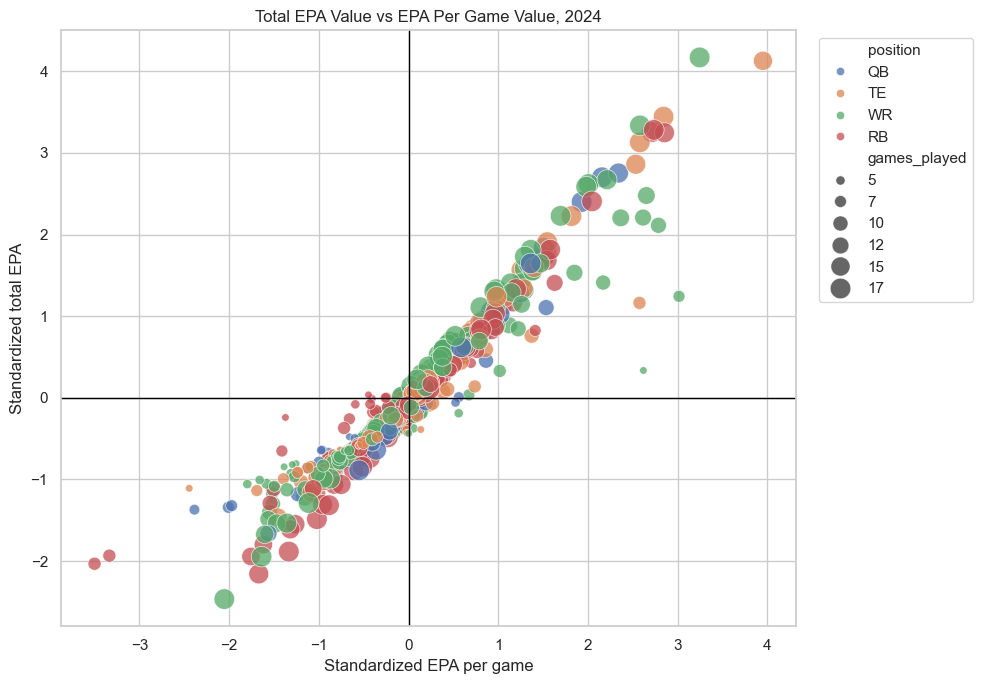

In [6]:
plot_df = value_scored[value_scored["season"] == season_to_check].copy()

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=plot_df,
    x="value_score_per_game",
    y="value_score",
    hue="position",
    size="games_played",
    sizes=(30, 220),
    alpha=0.75
)
plt.axhline(0, color="black", linewidth=1)
plt.axvline(0, color="black", linewidth=1)
plt.title("Total EPA Value vs EPA Per Game Value, " + str(season_to_check))
plt.xlabel("Standardized EPA per game")
plt.ylabel("Standardized total EPA")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## Top Player-Seasons Overall

This table ranks the strongest player-seasons by raw total EPA across the full dataset.

Because QBs handle the ball on many more plays than other positions, raw total EPA is not position-neutral. I use this table for interpretation, but the standardized `value_score` is still the better cross-position comparison.


In [7]:
value_scored[[
    "season", "player_display_name", "position", "team", "games_played",
    "value_epa_total", "value_epa_per_game", "value_score",
    "value_score_per_game", "position_season_rank"
]].sort_values("value_epa_total", ascending=False).head(25)


,season,player_display_name,position,team,games_played,value_epa_total,value_epa_per_game,value_score,value_score_per_game,position_season_rank
1273,2018,Patrick Mahomes,QB,KC,16,237.035261,14.814704,3.281056,2.671036,1.0
2956,2022,Patrick Mahomes,QB,KC,17,217.440698,12.790629,3.929853,2.889368,1.0
2068,2020,Patrick Mahomes,QB,KC,15,203.585468,13.572365,2.729479,2.401074,1.0
1745,2019,Lamar Jackson,QB,BAL,15,198.891739,13.259449,3.149791,2.525299,1.0
1841,2020,Aaron Rodgers,QB,GB,16,189.192151,11.824509,2.502075,2.051111,2.0
3894,2024,Josh Allen,QB,BUF,16,187.113574,11.694598,2.753053,2.341023,1.0
3885,2024,Lamar Jackson,QB,BAL,17,183.931545,10.819503,2.701035,2.157571,2.0
4655,2025,Drake Maye,QB,NE,17,176.374409,10.374965,3.045983,2.072520,1.0
2171,2020,Josh Allen,QB,BUF,16,169.031357,10.564460,2.183548,1.798819,3.0
37,2016,Matt Ryan,QB,ATL,16,166.575950,10.410997,2.599548,1.985374,1.0


## Standardized Value Distribution by Position

This boxplot shows the spread of `value_score` by position. Since the metric is standardized within season-position groups, the center of each position should be near zero.

The main thing I am checking is whether any position has strange outliers or an unexpected distribution shape that would affect later modeling.


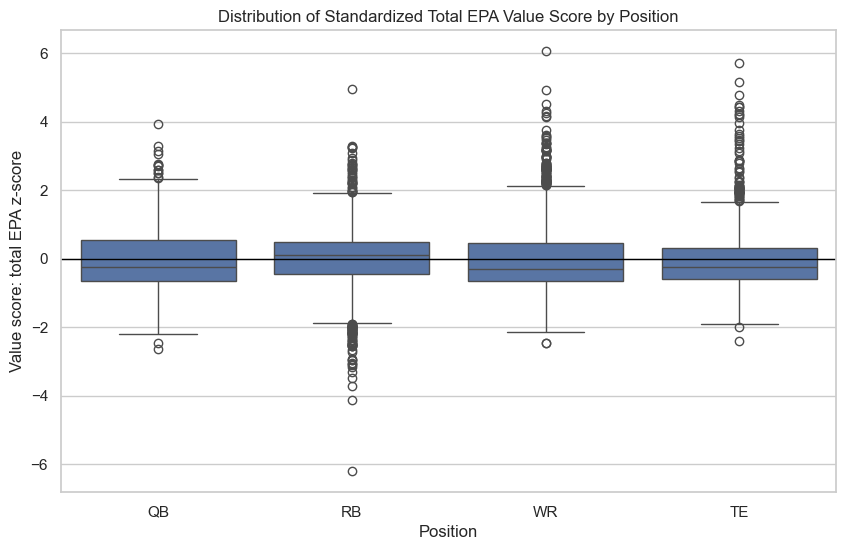

In [8]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=value_scored, x="position", y="value_score", order=["QB", "RB", "WR", "TE"])
plt.axhline(0, color="black", linewidth=1)
plt.title("Distribution of Standardized Total EPA Value Score by Position")
plt.xlabel("Position")
plt.ylabel("Value score: total EPA z-score")
plt.show()


## Raw Total EPA Distribution by Position

This plot keeps the metric in raw EPA units, which is easier to explain to a nontechnical reader: higher values mean more expected points added.

The tradeoff is that raw EPA is not automatically fair across positions because roles and opportunity levels are different.


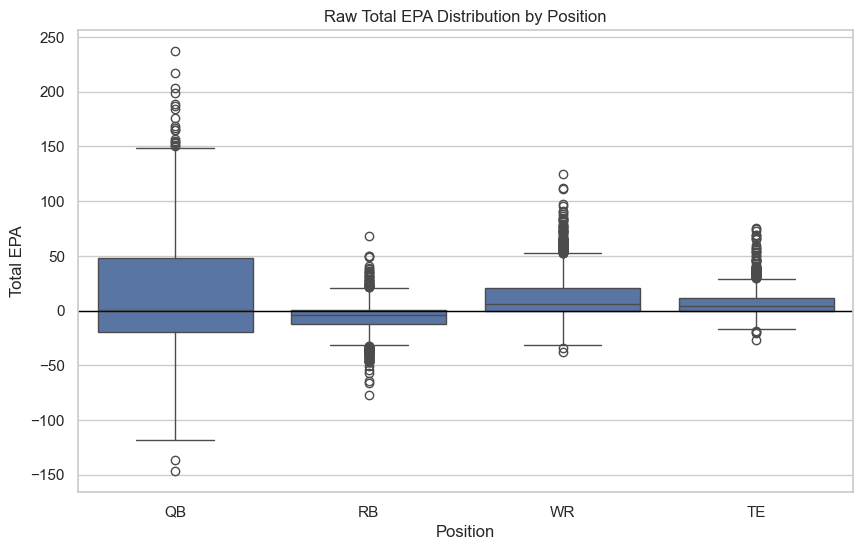

In [9]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=value_scored, x="position", y="value_epa_total", order=["QB", "RB", "WR", "TE"])
plt.axhline(0, color="black", linewidth=1)
plt.title("Raw Total EPA Distribution by Position")
plt.xlabel("Position")
plt.ylabel("Total EPA")
plt.show()


## Age Curves by Position

This chart looks for broad age-related patterns in value. I am using it descriptively, not causally.

Age curves can be noisy because the players who remain in the league at older ages are usually the ones who were already good enough to survive roster cuts. That selection effect is important to keep in mind.


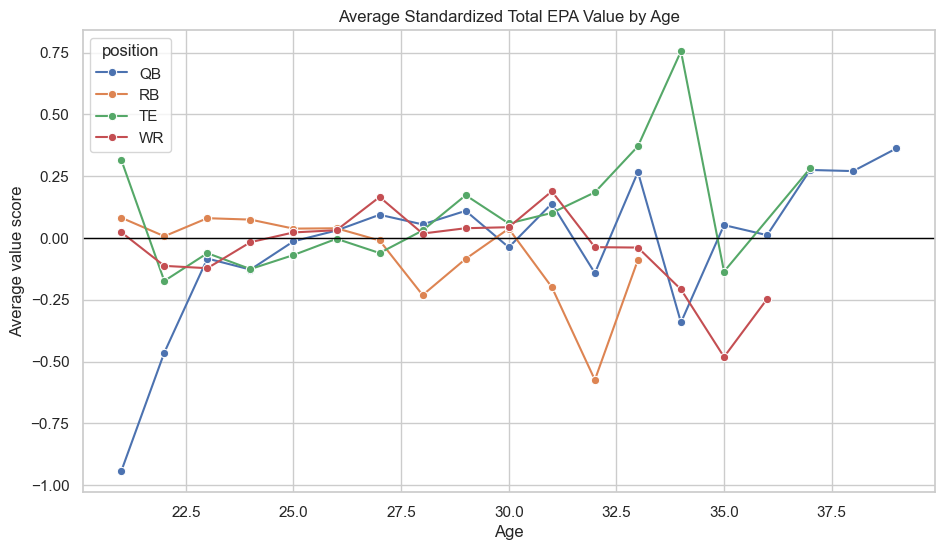

In [10]:
age_curve = (
    value_scored
    .dropna(subset=["age", "value_score"])
    .assign(age=lambda df: df["age"].round().astype(int))
    .groupby(["position", "age"], as_index=False)
    .agg(
        avg_value_score=("value_score", "mean"),
        avg_total_epa=("value_epa_total", "mean"),
        n=("player_id", "count")
    )
    .query("n >= 5")
)

plt.figure(figsize=(11, 6))
sns.lineplot(data=age_curve, x="age", y="avg_value_score", hue="position", marker="o")
plt.axhline(0, color="black", linewidth=1)
plt.title("Average Standardized Total EPA Value by Age")
plt.xlabel("Age")
plt.ylabel("Average value score")
plt.show()


## Experience Curves by Position

This view uses `years_exp` to look at career-stage patterns. It helps separate age from NFL experience, although the two are obviously related.

I am mainly looking for whether value appears to rise, flatten, or decline at different points for each position.


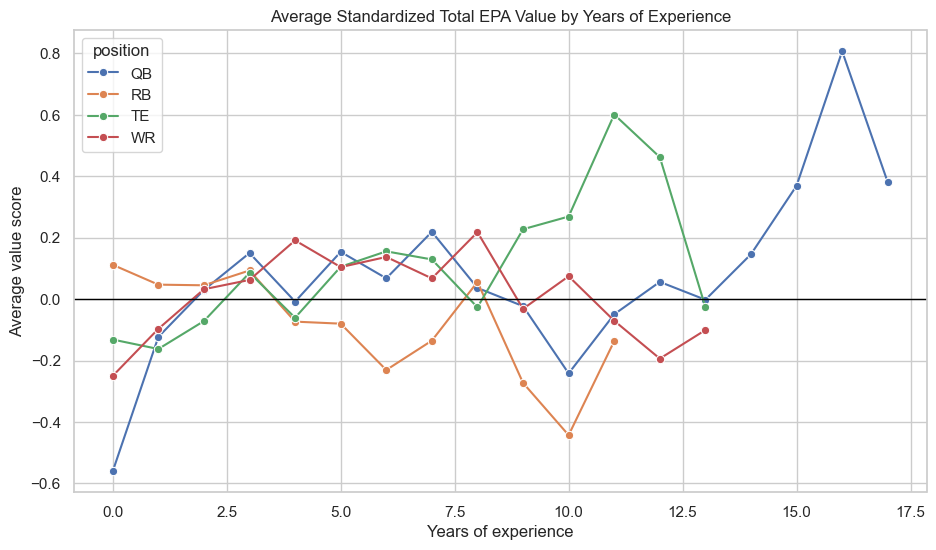

In [11]:
exp_curve = (
    value_scored
    .dropna(subset=["years_exp", "value_score"])
    .assign(years_exp=lambda df: df["years_exp"].round().astype(int))
    .groupby(["position", "years_exp"], as_index=False)
    .agg(
        avg_value_score=("value_score", "mean"),
        avg_total_epa=("value_epa_total", "mean"),
        n=("player_id", "count")
    )
    .query("n >= 5")
)

plt.figure(figsize=(11, 6))
sns.lineplot(data=exp_curve, x="years_exp", y="avg_value_score", hue="position", marker="o")
plt.axhline(0, color="black", linewidth=1)
plt.title("Average Standardized Total EPA Value by Years of Experience")
plt.xlabel("Years of experience")
plt.ylabel("Average value score")
plt.show()


## Per-Game Outliers

This table highlights players whose per-game score is much higher than their total-EPA score.

These are useful edge cases. Some players may have been excellent in limited time, while others may be small-sample outliers. Either way, they are exactly the kind of cases where a single metric needs context.


In [12]:
value_scored[[
    "season", "player_display_name", "position", "team", "games_played",
    "value_epa_total", "value_epa_per_game", "value_score",
    "value_score_per_game", "value_score_gap"
]].sort_values("value_score_gap", ascending=False).head(25)


,season,player_display_name,position,team,games_played,value_epa_total,value_epa_per_game,value_score,value_score_per_game,value_score_gap
4280,2025,Tyreek Hill,WR,MIA,4,19.834595,4.958649,0.485252,3.123034,2.637781
4168,2024,Rashee Rice,WR,KC,4,18.822884,4.705721,0.334204,2.618658,2.284454
2409,2021,Maxx Williams,TE,ARI,5,15.071474,3.014295,0.651363,2.655027,2.003664
2082,2020,Kenny Golladay,WR,DET,5,21.662457,4.332491,0.323285,2.177976,1.854691
3854,2024,Chris Godwin Jr.,WR,TB,7,37.047007,5.292430,1.242907,3.015797,1.772891
2339,2021,Antonio Brown,WR,TB,7,34.262215,4.894602,1.099235,2.832960,1.733725
1680,2019,Will Dissly,TE,SEA,6,19.106299,3.184383,0.820208,2.522429,1.702221
4588,2025,Tucker Kraft,TE,GB,8,38.442761,4.805345,2.054947,3.670778,1.615831
4680,2025,Ashton Jeanty,RB,LV,17,-77.057753,-4.532809,-6.206965,-4.616463,1.590502
4656,2025,Jalen McMillan,WR,TB,4,12.027500,3.006875,0.071737,1.658745,1.587008


## Correlation With Supporting Statistics

The heatmap and correlation table show how the value metrics relate to supporting variables like games played, yards, touchdowns, age, experience, and efficiency.

I am not treating these correlations as causal. The goal is to understand which variables move with the value score and which variables may be redundant if used together in a model.


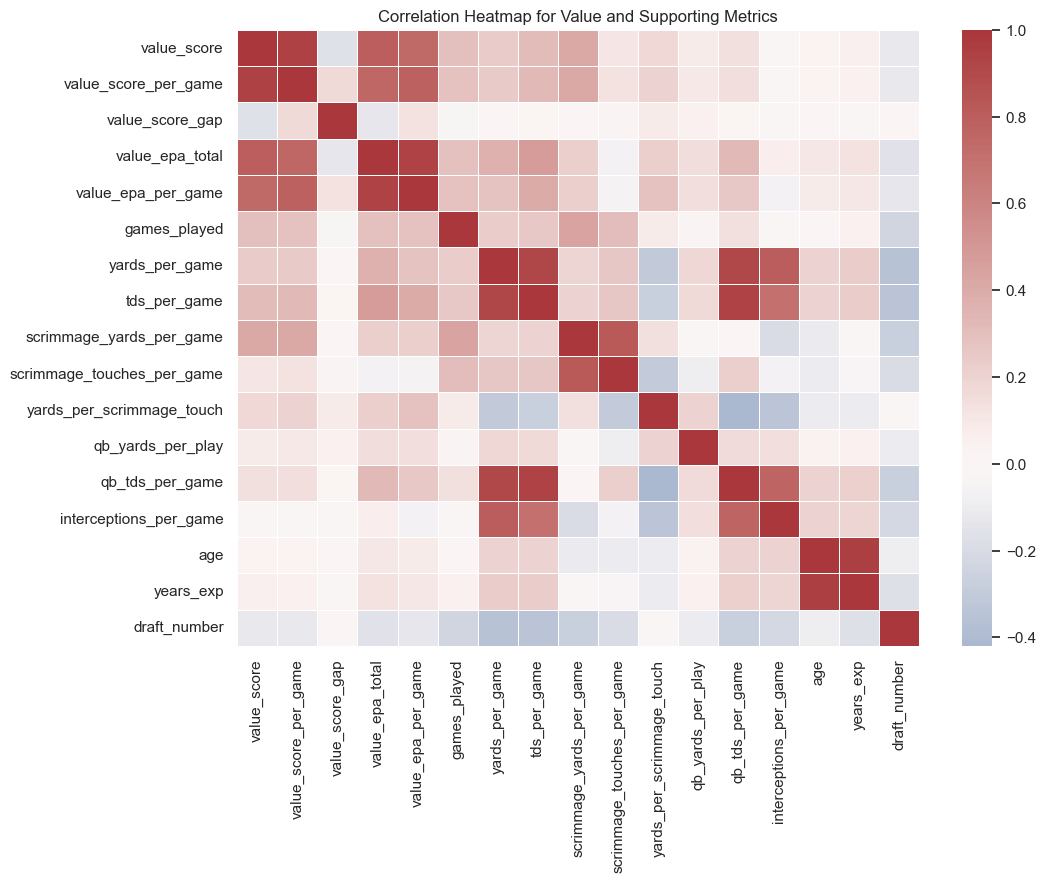

value_score                   1.000000
value_score_per_game          0.945340
value_epa_total               0.796605
value_epa_per_game            0.735910
scrimmage_yards_per_game      0.416363
tds_per_game                  0.313868
games_played                  0.298636
yards_per_game                0.237958
yards_per_scrimmage_touch     0.178724
qb_tds_per_game               0.137735
scrimmage_touches_per_game    0.116737
qb_yards_per_play             0.079384
years_exp                     0.057449
age                           0.035685
interceptions_per_game       -0.022936
draft_number                 -0.120078
value_score_gap              -0.165318
Name: value_score, dtype: float64

In [13]:
supporting_cols = [
    "value_score", "value_score_per_game", "value_score_gap",
    "value_epa_total", "value_epa_per_game", "games_played",
    "yards_per_game", "tds_per_game", "scrimmage_yards_per_game",
    "scrimmage_touches_per_game", "yards_per_scrimmage_touch",
    "qb_yards_per_play", "qb_tds_per_game", "interceptions_per_game",
    "age", "years_exp", "draft_number"
]

available_cols = [col for col in supporting_cols if col in value_scored.columns]

corr = value_scored[available_cols].corr(numeric_only=True)
plt.figure(figsize=(11, 8))
sns.heatmap(corr, cmap="vlag", center=0, linewidths=0.5)
plt.title("Correlation Heatmap for Value and Supporting Metrics")
plt.show()

corr["value_score"].sort_values(ascending=False)


## Methodological Notes

The current design separates raw production from standardized comparison.

- `value_epa_total` is the primary raw value metric because it measures full-season production.
- `value_score` is the main comparison metric because it standardizes total EPA within season-position groups.
- `value_epa_per_game` is kept as context, especially for players with limited games.
- Supporting stats help explain the value score, but they are not part of the value-score formula.

The main limitation is that this is still a production-based metric. It does not fully capture blocking, route quality, scheme, offensive line effects, injuries, teammate effects, or defensive attention. This matters most for tight ends because blocking value is not well represented in the current data.
